# Generation Performance Figures

Longitudinal generation calibration panels.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

%matplotlib inline

CWD = Path.cwd().resolve()
FIGURE_DIR = CWD if (CWD / "figutils").exists() else CWD / "figure"
REPO_ROOT = FIGURE_DIR.parent
INPUT_DIR = REPO_ROOT / "results" / "generation_longitudinal_0506"
LABELS_CHAPTER_PATH = REPO_ROOT.parent / "data" / "labels_chapter.csv"
OUTPUT_DIR = FIGURE_DIR / "out"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

font_path = FIGURE_DIR / "figutils" / "Helvetica.ttf"
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()

COLOR_REMAP = {
    "#98df8a": "#91c987",
    "#ff7f0e": "#ec713f",
    "#ff9896": "#dd5752",
    "#2ca02c": "#4f7951",
    "#9edae5": "#90c0c2",
    "#7f7f7f": "#87776a",
    "#dbdb8d": "#e6c186",
    "#d62728": "#c34a54",
    "#17becf": "#567797",
    "#8c564b": "#6b512a",
    "#1f77b4": "#2964b8",
    "#ffbb78": "#f7b141",
    "#e377c2": "#e45c88",
    "#FFFF00": "#E7C547",
    "#000a35": "#1d1f20",
}

In [2]:
def _chapter_order_key(label: str):

    roman = {"I": 1, "V": 5, "X": 10, "L": 50, "C": 100, "D": 500, "M": 1000}
    prefix = str(label).split(".", 1)[0].split("/", 1)[0].strip().upper()
    if not prefix or any(ch not in roman for ch in prefix):
        return (10_000, str(label))
    total, prev = 0, 0
    for ch in reversed(prefix):
        val = roman[ch]
        total += -val if val < prev else val
        prev = val
    return (total, str(label))


def _legend_label(chapter: str) -> str:
    """legend 표기용 이름. 'XX. Diabetes drugs' 는 'Diabetes Drugs' 로 보여준다."""
    if str(chapter).strip() == "XX. Diabetes drugs":
        return "Diabetes Drugs"
    return str(chapter)


def _ecdf(values: np.ndarray):
    values = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(values) + 1, dtype=float) / max(len(values), 1)
    return values, y


def _set_equal_log_xy(ax, lo: float, hi: float):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")


def draw_panel_a(ax, per_patient: pd.DataFrame):
    observed = per_patient["true_events"].to_numpy(dtype=float)
    generated = per_patient["generated_events"].to_numpy(dtype=float)
    ax.scatter(observed + 1, generated + 1, s=18, alpha=0.55, color="#4c78a8", edgecolors="none")
    max_count = max(float(np.nanmax(observed)), float(np.nanmax(generated)), 1.0) + 1
    diag = np.array([1, max_count + 1])
    ax.plot(diag, diag, color="black", linestyle=":", linewidth=1.2, label="perfect count")
    _set_equal_log_xy(ax, 0.8, max_count * 1.2)
    ax.set_xlabel("Observed future events per patient")
    ax.set_ylabel("Generated future events per patient")
    for spine in ax.spines.values():
        spine.set_visible(False)


def load_chapter_meta(labels_chapter_path: Path | None) -> pd.DataFrame:
    if labels_chapter_path is None or not labels_chapter_path.exists():
        return pd.DataFrame(columns=["token", "chapter", "color"])
    meta = pd.read_csv(labels_chapter_path)
    return (
        meta.rename(columns={"token_id": "token", "Short Chapter": "chapter"})[
            ["token", "chapter", "color"]
        ]
        .drop_duplicates("token")
        .copy()
    )


def draw_token_chapter_scatter(
    ax,
    freq: pd.DataFrame,
    chapter_meta: pd.DataFrame,
    summary: dict,
    highlight_drugs: bool = True,
    jitter: float = 0.0,
):
    work = freq.merge(chapter_meta, on="token", how="left")
    work["chapter"] = work["chapter"].fillna("Unknown")
    work["color"] = work["color"].fillna("#999999")
    work = work[~work["chapter"].isin(["Technical", "Sex", "Smoking, Alcohol and BMI"])].copy()

    floor = 0.5 / max(
        float(summary["true_future_clinical_events"]),
        float(summary["generated_future_clinical_events"]),
        1.0,
    )
    work["x"] = work["observed_ratio"].clip(lower=floor)
    work["y"] = work["generated_ratio"].clip(lower=floor)
    work["is_drug"] = work["chapter"].eq("XX. Diabetes drugs")
    work["abs_log_gap"] = (np.log10(work["y"]) - np.log10(work["x"])).abs()

    if jitter and jitter > 0:
        rng = np.random.default_rng(0)
        work["x"] = work["x"] * 10.0 ** rng.normal(0.0, jitter, len(work))
        work["y"] = work["y"] * 10.0 ** rng.normal(0.0, jitter, len(work))

    for chapter, sub in work.groupby("chapter", sort=False):
        if chapter == "XX. Diabetes drugs" and highlight_drugs:
            continue
        ax.scatter(
            sub["x"],
            sub["y"],
            s=30,
            alpha=0.70,
            c=sub["color"],
            edgecolors="none",
            label=chapter,
        )

    drug = work[work["is_drug"]]
    if highlight_drugs and not drug.empty:
        ax.scatter(
            drug["x"],
            drug["y"],
            s=70,
            alpha=0.95,
            c=drug["color"],
            edgecolors="black",
            linewidths=0.7,
            label="XX. Diabetes drugs",
            zorder=5,
        )

    lo = floor * 0.8
    hi = max(float(work["x"].max()), float(work["y"].max()), floor) * 1.7
    ax.plot([lo, hi], [lo, hi], color="black", linestyle=":", linewidth=1.2)
    _set_equal_log_xy(ax, lo, hi)
    ax.set_xlabel("Observed token rate")
    ax.set_ylabel("Generated token rate")
    for spine in ax.spines.values():
        spine.set_visible(False)

    palette = work.drop_duplicates("chapter").set_index("chapter")["color"].to_dict()
    handles = [
        Line2D(
            [0], [0], marker="o", linestyle="", markersize=7,
            markerfacecolor=palette[ch], markeredgecolor="black", markeredgewidth=0.7,
            alpha=1.0, label=_legend_label(ch),
        )
        for ch in sorted(palette, key=_chapter_order_key)
    ]
    if handles:
        ax.legend(
            handles=handles,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            ncol=1,
            fontsize=8,
        )


def draw_token_chapter_count_scatter(
    ax,
    freq: pd.DataFrame,
    chapter_meta: pd.DataFrame,
    summary: dict,
    title: str = "A''. Token-level count calibration",
    highlight_drugs: bool = True,
    jitter: float = 0.0,
):
    work = freq.merge(chapter_meta, on="token", how="left")
    work["chapter"] = work["chapter"].fillna("Unknown")
    work["color"] = work["color"].fillna("#999999")
    work = work[~work["chapter"].isin(["Technical", "Sex", "Smoking, Alcohol and BMI", "Death"])].copy()

    count_offset = 0.5
    work["x"] = work["observed_count"].astype(float) + count_offset
    work["y"] = work["generated_count"].astype(float) + count_offset
    work["is_drug"] = work["chapter"].eq("XX. Diabetes drugs")
    work["abs_count_gap"] = (work["generated_count"] - work["observed_count"]).abs()

    if jitter and jitter > 0:
        rng = np.random.default_rng(0)
        work["x"] = work["x"] * 10.0 ** rng.normal(0.0, jitter, len(work))
        work["y"] = work["y"] * 10.0 ** rng.normal(0.0, jitter, len(work))

    for chapter, sub in work.groupby("chapter", sort=False):
        if chapter == "XX. Diabetes drugs" and highlight_drugs:
            continue
        ax.scatter(
            sub["x"],
            sub["y"],
            s=30,
            alpha=0.70,
            c=sub["color"],
            edgecolors="none",
            label=chapter,
        )

    drug = work[work["is_drug"]]
    if highlight_drugs and not drug.empty:
        ax.scatter(
            drug["x"],
            drug["y"],
            s=70,
            alpha=0.95,
            c=drug["color"],
            edgecolors="black",
            linewidths=0.7,
            label="XX. Diabetes drugs",
            zorder=5,
        )

    lo = count_offset * 0.7
    hi = max(float(work["x"].max()), float(work["y"].max()), 1.0) * 1.7
    ax.plot([lo, hi], [lo, hi], color="black", linestyle=":", linewidth=1.2, label="perfect token count")
    cohort_ratio = float(summary["event_count_ratio_generated_over_observed"])
    ax.plot(
        [lo, hi],
        [lo * cohort_ratio, hi * cohort_ratio],
        color="#444444",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        label=f"overall count ratio={cohort_ratio:.3f}",
    )
    _set_equal_log_xy(ax, lo, hi)
    ax.set_xlabel("Observed token count in kr_test + 0.5")
    ax.set_ylabel("Generated token count + 0.5")
    ax.set_title(f"{title}\nEach point is one clinical token, colored by ICD chapter")

    handles, labels = ax.get_legend_handles_labels()
    if handles:
        order = sorted(range(len(labels)), key=lambda i: _chapter_order_key(labels[i]))
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        ax.legend(
            handles,
            labels,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
            ncol=1,
            fontsize=6.5,
        )


def draw_panel_b(ax, events: pd.DataFrame):
    observed = events.loc[events["source"] == "observed", "age_year"].dropna().to_numpy(dtype=float)
    generated = events.loc[events["source"] == "generated", "age_year"].dropna().to_numpy(dtype=float)
    x_obs, y_obs = _ecdf(observed)
    x_gen, y_gen = _ecdf(generated)

    grid = np.union1d(x_obs, x_gen)

    ax.plot(x_obs, y_obs, label="Observed", color="#2F6B9A", linewidth=2.0)
    ax.plot(x_gen, y_gen, label="Generated", color="#C05A3D", linewidth=2.0, linestyle="--")
    ax.set_xlabel("Absolute age at future event (years)")
    ax.set_ylabel("Empirical CDF")
    ax.legend(frameon=False, loc="lower right", fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def _chapter_work(freq: pd.DataFrame, chapter_meta: pd.DataFrame) -> pd.DataFrame:
    work = freq.merge(chapter_meta, on="token", how="left")
    work["chapter"] = work["chapter"].fillna("Unknown")
    work["color"] = work["color"].fillna("#999999")
    exclude = {"Technical", "Sex", "Smoking, Alcohol and BMI", "Death", "Unknown"}
    return work[~work["chapter"].isin(exclude)].copy()


def _chapter_summary(freq: pd.DataFrame, chapter_meta: pd.DataFrame) -> pd.DataFrame:
    work = _chapter_work(freq, chapter_meta)
    chapter = (
        work.groupby("chapter", as_index=False)
        .agg(
            observed_count=("observed_count", "sum"),
            generated_count=("generated_count", "sum"),
            color=("color", "first"),
        )
        .copy()
    )
    obs_total = max(float(chapter["observed_count"].sum()), 1.0)
    gen_total = max(float(chapter["generated_count"].sum()), 1.0)
    chapter["observed_frac"] = chapter["observed_count"] / obs_total
    chapter["generated_frac"] = chapter["generated_count"] / gen_total
    chapter["combined_count"] = chapter["observed_count"] + chapter["generated_count"]
    chapter["abs_frac_gap"] = (chapter["generated_frac"] - chapter["observed_frac"]).abs()
    return chapter.sort_values("combined_count", ascending=False)


def draw_chapter_bubble_scatter(
    ax,
    freq: pd.DataFrame,
    chapter_meta: pd.DataFrame,
    title: str = "C. ICD chapter composition parity",
    size_tiers: list[tuple[float, float]] | None = None,
    axis_min: float = -0.02,
    legend_marker_scale: float = 0.55,
    small_jitter: float = 0.006,
    jitter_below: float | None = None,
):
    chapter = _chapter_summary(freq, chapter_meta)
    if chapter.empty:
        ax.text(0.5, 0.5, "No chapter data", ha="center", va="center")
        return

    if size_tiers is None:
        size_tiers = [
            (8000, 1000.0),  # Tier 1 (대):   combined >= 8,000
            (3000, 600.0),   # Tier 2 (중):   3,000 <= combined < 8,000
            (1000, 200.0),   # Tier 3 (소):   1,000 <= combined < 3,000
            (0, 50.0),       # Tier 4 (극소): combined < 1,000
        ]

    def _tier_size(count: float) -> float:
        for thresh, size in size_tiers:
            if count >= thresh:
                return float(size)
        return float(size_tiers[-1][1])

    sizes = chapter["combined_count"].map(_tier_size).to_numpy(dtype=float)

    xs = chapter["observed_frac"].to_numpy(dtype=float).copy()
    ys = chapter["generated_frac"].to_numpy(dtype=float).copy()
    if small_jitter and small_jitter > 0:
        thr_small = jitter_below if jitter_below is not None else (
            size_tiers[-2][0] if len(size_tiers) >= 2 else 0.0
        )
        small_mask = chapter["combined_count"].to_numpy(dtype=float) < float(thr_small)
        if small_mask.any():
            rng = np.random.default_rng(0)
            n = int(small_mask.sum())
            xs[small_mask] = xs[small_mask] + rng.uniform(-small_jitter, small_jitter, n)
            ys[small_mask] = ys[small_mask] + rng.uniform(-small_jitter, small_jitter, n)

    ax.scatter(
        xs,
        ys,
        s=sizes,
        c=chapter["color"],
        alpha=0.78,
        edgecolors="black",
        linewidths=0.55,
        zorder=2,
    )

    hi = max(float(chapter["observed_frac"].max()), float(chapter["generated_frac"].max())) * 1.1
    hi = max(hi, 0.08)
    ax.plot([axis_min, hi], [axis_min, hi], color="black", linestyle=":", linewidth=1.2, zorder=0)
    ax.set_xlim(axis_min, hi)
    ax.set_ylim(axis_min, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Observed disease share")
    ax.set_ylabel("Generated disease share")
    for spine in ax.spines.values():
        spine.set_visible(False)

    tier_labels = []
    for i, (thr, _size) in enumerate(size_tiers):
        upper = size_tiers[i - 1][0] if i > 0 else None
        if upper is None:
            tier_labels.append(f"\u2265 {int(thr):,}")
        elif thr == 0:
            tier_labels.append(f"< {int(upper):,}")
        else:
            tier_labels.append(f"{int(thr):,}\u2013{int(upper):,}")
    size_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="",
            markerfacecolor="black", markeredgecolor="none", markeredgewidth=0.55,
            alpha=0.95, markersize=float(np.sqrt(size) * legend_marker_scale), label=lab,
        )
        for (thr, size), lab in zip(size_tiers, tier_labels)
    ]
    ax.legend(
        handles=size_handles,
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        labelspacing=1.7,
        handletextpad=1.0,
        fontsize=9,
    )

In [3]:
summary = json.loads((INPUT_DIR / "summary.json").read_text())
per_patient = pd.read_csv(INPUT_DIR / "per_patient.csv")
events = pd.read_csv(INPUT_DIR / "clinical_events.csv")
freq = pd.read_csv(INPUT_DIR / "token_frequency.csv")
chapter_meta = load_chapter_meta(LABELS_CHAPTER_PATH)
chapter_meta["color"] = chapter_meta["color"].replace(COLOR_REMAP)

TOKEN_JITTER = 0.08

print(f"INPUT_DIR  = {INPUT_DIR}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"freq rows  = {len(freq)}, chapter_meta rows = {len(chapter_meta)}")

INPUT_DIR  = /home/hsh/hsh/GPT-Disease-Drug-Prediction/results/generation_longitudinal_0506
OUTPUT_DIR = /home/hsh/hsh/GPT-Disease-Drug-Prediction/figure/out
freq rows  = 674, chapter_meta rows = 1289


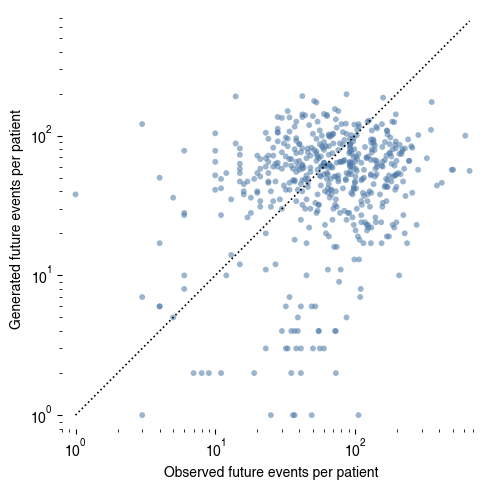

In [4]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
draw_panel_a(ax, per_patient)
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "gen_patient_event_count_scatter.pdf", bbox_inches="tight")
plt.show()

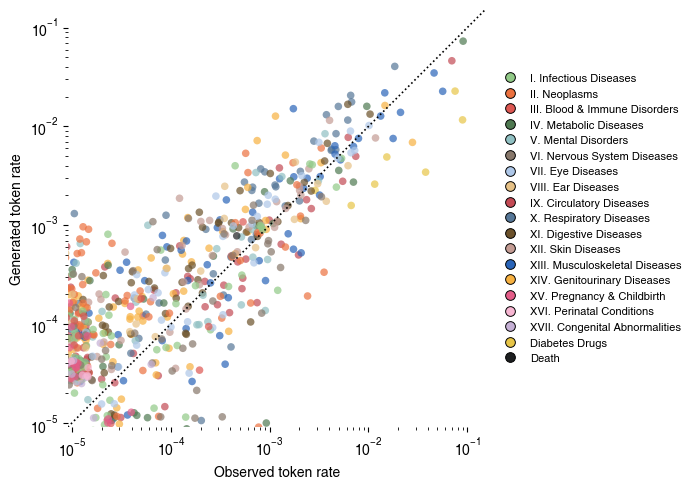

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 5.0))
draw_token_chapter_scatter(ax, freq, chapter_meta, summary, highlight_drugs=False, jitter=TOKEN_JITTER)
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "gen_token_chapter_scatter.pdf", bbox_inches="tight")
plt.show()

In [7]:
# fig, ax = plt.subplots(figsize=(7.8, 5.0))
# draw_token_chapter_count_scatter(ax, freq, chapter_meta, summary, highlight_drugs=False, jitter=0.15)
# fig.tight_layout()
# # fig.savefig(OUTPUT_DIR / "gen_token_chapter_count_scatter.png", bbox_inches="tight")
# plt.show()

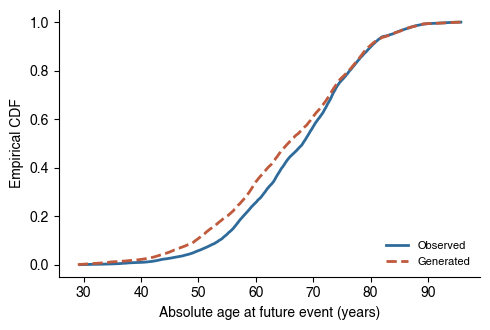

In [8]:
fig, ax = plt.subplots(figsize=(5.0, 3.4))
draw_panel_b(ax, events)
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "gen_future_age_ecdf.pdf", bbox_inches="tight")
plt.show()

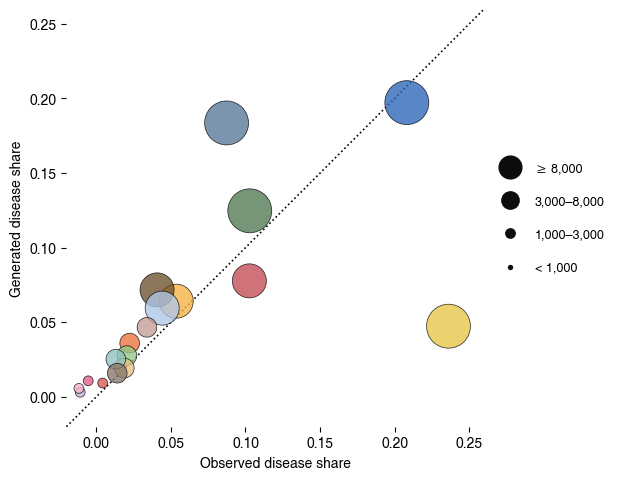

In [9]:
fig, ax = plt.subplots(figsize=(5.8, 5.2))
draw_chapter_bubble_scatter(ax, freq, chapter_meta, small_jitter=0.012)
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / "gen_chapter_bubble_scatter.pdf", bbox_inches="tight")
plt.show()

## Trajectory Generation Example

Render the longitudinal generation figure for `SELECTED_PATIENT_ID`.


In [ ]:
from __future__ import annotations

from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import numpy as np
import pandas as pd

CWD = Path.cwd().resolve()
FIGURE_DIR = CWD if (CWD / "figutils").exists() else CWD / "figure"
REPO_ROOT = FIGURE_DIR.parent
FIGURE_OUT_DIR = FIGURE_DIR / "out"
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "generation_longitudinal_0506_n10000_20260601"
GEN_RUN_DIR = REPO_ROOT / "results" / RUN_NAME
RUN_LOG_PATH = REPO_ROOT / "logs" / f"{RUN_NAME}.log"
PER_PATIENT_PATH = GEN_RUN_DIR / "per_patient.csv"
EVENTS_PATH = GEN_RUN_DIR / "clinical_events.csv"
HISTORY_PATHS = [
    REPO_ROOT.parent / "data" / "kr_train.bin",
    REPO_ROOT.parent / "data" / "kr_val.bin",
]

SELECTED_PATIENT_ID = 85959583
HISTORY_EVENTS_TO_SHOW = None

USE_BUNDLED_HELVETICA = True
font_path = FIGURE_DIR / "figutils" / "Helvetica.ttf"
bold_font_path = FIGURE_DIR / "figutils" / "Helvetica Bold.ttf"
if USE_BUNDLED_HELVETICA and font_path.exists():
    fm.fontManager.addfont(str(font_path))
    plt.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()
if USE_BUNDLED_HELVETICA and bold_font_path.exists():
    fm.fontManager.addfont(str(bold_font_path))
if not USE_BUNDLED_HELVETICA:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams.update(
    {
        "pdf.fonttype": 3,
        "ps.fonttype": 42,
        "axes.linewidth": 1.0,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [11]:
MIN_DISEASE_TOKEN = 22
FIRST_DRUG_TOKEN = 1278
LAST_DRUG_TOKEN = 1287
DEATH_TOKEN = 1288

COMPOSITE_DTYPE = np.dtype(
    [
        ("ID", np.uint32),
        ("AGE", np.uint32),
        ("DATA", np.uint32),
        ("SHIFT", np.uint32),
        ("TOTAL", np.uint32),
    ]
)

def event_type(token: int, name: str | None = None) -> str:
    token = int(token)
    if token == DEATH_TOKEN or str(name) == "Death":
        return "Death"
    if FIRST_DRUG_TOKEN <= token <= LAST_DRUG_TOKEN:
        return "Medication"
    if MIN_DISEASE_TOKEN <= token < FIRST_DRUG_TOKEN:
        return "Disease"
    return "Other"

In [12]:
required_run_files = [PER_PATIENT_PATH, EVENTS_PATH]
missing = [path for path in required_run_files if not path.exists()]
if missing:
    missing_text = "\n".join(f"- {path}" for path in missing)
    log_hint = f"\nCheck progress with: tail -f {RUN_LOG_PATH}" if RUN_LOG_PATH.exists() else ""
    raise FileNotFoundError(
        f"The generation run is not complete yet. Missing files:\n{missing_text}{log_hint}"
    )

events = pd.read_csv(EVENTS_PATH)
events["event_type"] = [event_type(t, n) for t, n in zip(events["token"], events["name"])]
events = events.loc[events["event_type"] != "Other"].copy()
events = events.sort_values(["patient_id", "source", "age_year", "token"]).reset_index(drop=True)

per_patient = pd.read_csv(PER_PATIENT_PATH)


def load_history_index(paths: list[Path]) -> tuple[np.ndarray, dict[int, tuple[int, int]]]:
    arrays = [np.asarray(np.memmap(path, dtype=COMPOSITE_DTYPE, mode="r")) for path in paths]
    data = np.concatenate(arrays)
    order = np.lexsort((data["AGE"], data["ID"]))
    sorted_data = data[order]
    ids = sorted_data["ID"].astype(np.int64)
    starts = np.r_[0, np.flatnonzero(ids[1:] != ids[:-1]) + 1]
    ends = np.r_[starts[1:], len(ids)]
    index = {int(ids[start]): (int(start), int(end)) for start, end in zip(starts, ends)}
    return sorted_data, index


history_sorted, history_index = load_history_index(HISTORY_PATHS)


def patient_history(patient_id: int) -> pd.DataFrame:
    bounds = history_index.get(int(patient_id))
    if bounds is None:
        return pd.DataFrame(columns=["token", "age_year", "event_type"])
    start, end = bounds
    rows = history_sorted[start:end]
    df = pd.DataFrame(
        {
            "token": rows["DATA"].astype(np.int64),
            "age_year": rows["AGE"].astype(np.float64) / 365.25,
        }
    )
    df["event_type"] = df["token"].map(lambda t: event_type(int(t)))
    df = df.loc[df["event_type"] != "Other"].copy()
    return df.sort_values(["age_year", "token"]).reset_index(drop=True)


def patient_future(patient_id: int, source: str) -> pd.DataFrame:
    subset = events.loc[(events["patient_id"] == int(patient_id)) & (events["source"] == source)].copy()
    return subset.sort_values(["age_year", "token"]).reset_index(drop=True)


print(f"Using generation run: {GEN_RUN_DIR}")
print(f"Loaded future events for {events['patient_id'].nunique()} generated patients")
print(f"History index contains {len(history_index):,} patients")

Using generation run: /home/hsh/hsh/GPT-Disease-Drug-Prediction/results/generation_longitudinal_0506_n10000_20260601
Loaded future events for 9998 generated patients
History index contains 119,254 patients


In [13]:
selected_patient_id = int(SELECTED_PATIENT_ID)

def patient_plot_summary(patient_id: int) -> dict[str, float]:
    pp = per_patient.loc[per_patient["patient_id"] == int(patient_id)].iloc[0]
    return {
        "history_end_age": float(pp["history_end_age"]),
        "horizon_end_age": float(pp["horizon_end_age"]),
    }

def build_plot_events(patient_id: int) -> tuple[pd.DataFrame, dict[str, float]]:
    summary = patient_plot_summary(patient_id)
    history = patient_history(patient_id)
    observed = patient_future(patient_id, "observed")
    generated = patient_future(patient_id, "generated")

    cutoff = summary["history_end_age"]
    history_pre = history.loc[history["age_year"] <= cutoff].sort_values(["age_year", "token"]).copy()
    history_prefix = (
        history_pre.copy()
        if HISTORY_EVENTS_TO_SHOW is None
        else history_pre.tail(HISTORY_EVENTS_TO_SHOW).copy()
    )
    history_prefix["source"] = "history_prefix"

    observed = observed.copy()
    observed["source"] = "observed"

    generated = generated.copy()
    generated["source"] = "generated"

    cols = ["source", "event_type", "age_year", "token"]
    plot_df = pd.concat([history_prefix[cols], observed[cols], generated[cols]], ignore_index=True)
    return plot_df.sort_values(["age_year", "source", "token"]).reset_index(drop=True), summary

plot_events, plot_summary = build_plot_events(selected_patient_id)
print(f"Selected patient: {selected_patient_id} ({len(plot_events)} events)")

Selected patient: 85959583 (281 events)


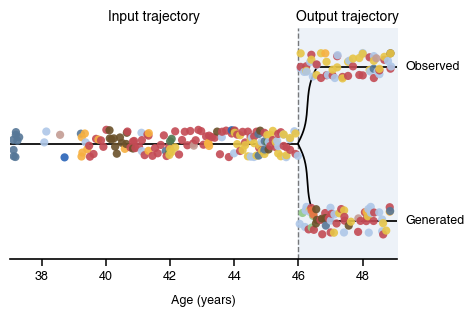

In [14]:
COLOR_REMAP = {
    "#98df8a": "#91c987",
    "#ff7f0e": "#ec713f",
    "#ff9896": "#dd5752",
    "#2ca02c": "#4f7951",
    "#9edae5": "#90c0c2",
    "#7f7f7f": "#87776a",
    "#dbdb8d": "#e6c186",
    "#d62728": "#c34a54",
    "#17becf": "#567797",
    "#8c564b": "#6b512a",
    "#1f77b4": "#2964b8",
    "#ffbb78": "#f7b141",
    "#e377c2": "#e45c88",
    "#FFFF00": "#E7C547",
    "#000a35": "#1d1f20",
}

LABELS_CHAPTER_PATH = REPO_ROOT.parent / "data" / "labels_chapter.csv"
_chapter_labels = pd.read_csv(LABELS_CHAPTER_PATH)
_chapter_labels.columns = ["name", "token_id", "chapter_full", "chapter_short", "color"]
_chapter_labels["token_id"] = pd.to_numeric(_chapter_labels["token_id"], errors="coerce")
_chapter_labels = _chapter_labels.dropna(subset=["token_id"]).copy()
_chapter_labels["token_id"] = _chapter_labels["token_id"].astype(int)
_chapter_labels["color"] = _chapter_labels["color"].replace(COLOR_REMAP)
TOKEN_COLOR_MAP = dict(zip(_chapter_labels["token_id"], _chapter_labels["color"]))

DEFAULT_TOKEN_COLOR = "#9aa3af"
GEN_MARKER_SIZE = 35
OBS_MARKER_SIZE = 35
HIST_MARKER_SIZE = 35
Y_JITTER = 0.18
BRACE_ROUNDNESS = 8.0

def color_for_token(token: int) -> str:
    if int(token) == DEATH_TOKEN:
        return "#111827"
    return TOKEN_COLOR_MAP.get(int(token), DEFAULT_TOKEN_COLOR)

def y_for_event(row: pd.Series) -> float:
    if row["source"] == "history_prefix":
        return 0.0
    if row["source"] == "observed":
        return 1.0
    if row["source"] == "generated":
        return -1.0
    return 0.0

def _curly_brace_xy(x_tip, depth, y_top=1.0, y_bot=-1.0, n=241, beta=8.0):
    x_base = x_tip + depth
    h = n // 2 + 1
    th = np.linspace(0.0, 1.0, h)
    half = 1.0 / (1.0 + np.exp(-beta * (th - th[0]))) + 1.0 / (1.0 + np.exp(-beta * (th - th[-1])))
    full = np.concatenate([half, half[-2::-1]])
    full = (full - full.min()) / (full.max() - full.min())
    ys = np.linspace(y_top, y_bot, full.size)
    xs = x_base - depth * full
    return xs, ys

def plot_trajectory_example(plot_df: pd.DataFrame, summary: dict[str, float]):
    cutoff = float(summary["history_end_age"])
    horizon = float(summary["horizon_end_age"])
    xmin = min(cutoff - 0.7, float(plot_df["age_year"].min()) - 0.1)
    xmax = max(horizon + 0.2, float(plot_df["age_year"].max()) + 0.1)

    fig, ax = plt.subplots(figsize=(5.0, 3.0))

    ax.axvspan(cutoff, xmax, color="#edf2f8", zorder=0)

    timeline_color = "black"
    timeline_lw = 1.25
    brace_width = float(np.clip((xmax - xmin) * 0.05, 0.28, 0.6))
    future_start = cutoff + brace_width
    ax.hlines(0.0, xmin, cutoff, color=timeline_color, linewidth=timeline_lw, zorder=1)
    ax.hlines([1.0, -1.0], future_start, xmax, color=timeline_color, linewidth=timeline_lw, zorder=1)

    brace_x, brace_y = _curly_brace_xy(cutoff, brace_width, y_top=1.0, y_bot=-1.0, beta=BRACE_ROUNDNESS)
    brace_codes = [MplPath.MOVETO] + [MplPath.LINETO] * (brace_x.size - 1)
    ax.add_patch(
        PathPatch(
            MplPath(np.column_stack([brace_x, brace_y]), brace_codes),
            facecolor="none",
            edgecolor=timeline_color,
            linewidth=timeline_lw,
            capstyle="round",
            joinstyle="round",
            zorder=1,
        )
    )
    ax.axvline(cutoff, color="black", linestyle="--", alpha=0.5, linewidth=1.0, zorder=2)

    rng = np.random.default_rng(0)
    for _, row in plot_df.iterrows():
        src = row["source"]
        is_death = row["event_type"] == "Death"
        face = color_for_token(int(row["token"]))
        size = 115 if is_death else (
            GEN_MARKER_SIZE if src == "generated" else (OBS_MARKER_SIZE if src == "observed" else HIST_MARKER_SIZE)
        )
        y = y_for_event(row) if is_death else y_for_event(row) + (
            rng.uniform(-Y_JITTER, Y_JITTER) if Y_JITTER > 0 else 0.0
        )
        ax.scatter(
            float(row["age_year"]),
            y,
            s=size,
            marker="o",
            facecolor=face,
            edgecolor="none",
            linewidth=0.6,
            alpha=0.75 if is_death else 0.9,
            zorder=5 if is_death else 3,
        )

    ax.set_yticks([])
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-1.5, 1.5)

    title_y = 1.56
    ax.text((xmin + cutoff) / 2.0, title_y, "Input trajectory", ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    ax.text((cutoff + xmax) / 2.0, title_y, "Output trajectory", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

    right_label_x = xmax + (xmax - xmin) * 0.02
    ax.text(right_label_x, 1.0, "Observed", ha="left", va="center", fontsize=9, clip_on=False)
    ax.text(right_label_x, -1.0, "Generated", ha="left", va="center", fontsize=9, clip_on=False)

    ax.set_xlabel("Age (years)", fontsize=9, labelpad=8)
    ax.tick_params(axis="x", labelsize=9, width=1.1, length=5)
    ax.tick_params(axis="y", length=0, pad=12)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(1.2)
    return fig

fig = plot_trajectory_example(plot_events, plot_summary)
# png_path = FIGURE_OUT_DIR / f"trajectory_example_patient{selected_patient_id}_order_age_final.png"
# pdf_path = FIGURE_OUT_DIR / f"trajectory_example_patient{selected_patient_id}_order_age_final.pdf"
# fig.savefig(png_path, bbox_inches="tight", facecolor="white")
# try:
#     fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
# except Exception as exc:
#     print(f"PDF save failed with {type(exc).__name__}: {exc}")
plt.show()

# print(f"Wrote {png_path}")
# print(f"Wrote {pdf_path}")